In [1]:
import kagglehub
import pandas as pd 
import os

# Download latest version
path = kagglehub.competition_download('titanic')

print("Path to competition files:", path)

test_path = os.path.join(path, "/kaggle/input/competitions/titanic/test.csv")
train_path = os.path.join(path, "/kaggle/input/competitions/titanic/train.csv")

test_df = pd.read_csv(test_path)
train_df = pd.read_csv(train_path)

print(train_df.head())

Path to competition files: /kaggle/input/competitions/titanic
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123     

In [2]:
print("-"*10)
print("TRAIN DATA")
print("-"*10)
print(train_df.isnull().sum())
print("-"*10)
print("TEST DATA")
print("-"*10)
print(test_df.isnull().sum())

----------
TRAIN DATA
----------
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
----------
TEST DATA
----------
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [3]:
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
print(train_df['Age'].isnull().sum())

0


In [4]:
train_df['Has_Cabin'] = train_df['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)
print(train_df['Cabin'].isnull().sum())
print(train_df['Has_Cabin'].isnull().sum())

687
0


In [5]:
train_df['Sex'] = train_df['Sex'].replace({'male': 0, 'female': 1})
print(train_df['Sex'])
print(train_df['Sex'].isnull().sum())

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    1
889    0
890    0
Name: Sex, Length: 891, dtype: int64
0


/tmp/ipykernel_16/3501505493.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df['Sex'] = train_df['Sex'].replace({'male': 0, 'female': 1})


In [6]:
moda_embarked = train_df['Embarked'].mode()[0]
train_df['Embarked'] = train_df['Embarked'].fillna(moda_embarked)

train_df['Embarked'] = train_df['Embarked'].replace({'C': 0, 'Q': 1, 'S': 2})
print(train_df[['Sex', 'Embarked']].head())

   Sex  Embarked
0    0         2
1    1         0
2    1         2
3    1         2
4    0         2


/tmp/ipykernel_16/185654198.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df['Embarked'] = train_df['Embarked'].replace({'C': 0, 'Q': 1, 'S': 2})


In [7]:
train_df['Deck'] = train_df['Cabin'].apply(lambda x: str(x)[0] if pd.notna(x) else 'Unknown')

print(train_df.groupby('Deck')['Survived'].mean())

Deck
A          0.466667
B          0.744681
C          0.593220
D          0.757576
E          0.750000
F          0.615385
G          0.500000
T          0.000000
Unknown    0.299854
Name: Survived, dtype: float64


In [8]:
train_df = pd.get_dummies(train_df, columns=['Deck'], prefix='Deck')


deck_columns = [col for col in train_df.columns if col.startswith('Deck_')]
train_df[deck_columns] = train_df[deck_columns].astype(int)


print("Nuevas columnas de cubiertas:")
print(train_df[deck_columns].head())

Nuevas columnas de cubiertas:
   Deck_A  Deck_B  Deck_C  Deck_D  Deck_E  Deck_F  Deck_G  Deck_T  \
0       0       0       0       0       0       0       0       0   
1       0       0       1       0       0       0       0       0   
2       0       0       0       0       0       0       0       0   
3       0       0       1       0       0       0       0       0   
4       0       0       0       0       0       0       0       0   

   Deck_Unknown  
0             1  
1             0  
2             1  
3             0  
4             1  


In [9]:
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1

print(train_df.groupby('FamilySize')['Survived'].mean())

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


In [10]:
#Calculamos el precio por persona
train_df['Fare_PP'] = train_df['Fare'] / train_df['FamilySize']

#Agrupamos las clases sociales
train_df['Fare_Bin'] = pd.qcut(train_df['Fare_PP'], 4, labels=[0, 1, 2, 3]).astype(int)
train_df.drop(['Fare', 'Fare_PP'], axis=1, inplace=True)

In [11]:
# Extraemos el título (la palabra que termina en punto)
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Agrupamos los títulos raros o de la nobleza
train_df['Title'] = train_df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
train_df['Title'] = train_df['Title'].replace(['Mlle', 'Ms'], 'Miss')
train_df['Title'] = train_df['Title'].replace('Mme', 'Mrs')

# Lo convertimos a números (One-Hot Encoding)
train_df = pd.get_dummies(train_df, columns=['Title'], prefix='Title')

# Ahora sí, borramos Name y Ticket
train_df.drop(['Name', 'Ticket'], axis=1, inplace=True)

<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_16/279594626.py:2: SyntaxWarning: invalid escape sequence '\.'
  train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [12]:
# Cabin: Ya extrajimos la información útil en 'Deck' y 'Has_Cabin'.
# Sibsp y Parch: Ya tenemos la data en FamilySize
features_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch']

train_df.drop(columns=[col for col in features_to_drop if col in train_df.columns], inplace=True)

print("Columnas que quedaron para el modelo:")
print(train_df.columns.tolist())
print("\nVista previa de los datos listos:")
print(train_df.head())
print("\nVista de datos nulls finales")
print("-"*10)
print("TRAIN DATA")
print("-"*10)
print(train_df.isnull().sum())
print("-"*10)
print("TEST DATA")
print("-"*10)
print(test_df.isnull().sum())

Columnas que quedaron para el modelo:
['Survived', 'Pclass', 'Sex', 'Age', 'Embarked', 'Has_Cabin', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown', 'FamilySize', 'Fare_Bin', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']

Vista previa de los datos listos:
   Survived  Pclass  Sex   Age  Embarked  Has_Cabin  Deck_A  Deck_B  Deck_C  \
0         0       3    0  22.0         2          0       0       0       0   
1         1       1    1  38.0         0          1       0       0       1   
2         1       3    1  26.0         2          0       0       0       0   
3         1       1    1  35.0         2          1       0       0       1   
4         0       3    0  35.0         2          0       0       0       0   

   Deck_D  ...  Deck_G  Deck_T  Deck_Unknown  FamilySize  Fare_Bin  \
0       0  ...       0       0             1           2         0   
1       0  ...       0       0             0           2   

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# X = todas las columnas excepto 'Survived' (nuestras herramientas de predicción)
# y = la columna 'Survived' (lo que queremos adivinar)
X = train_df.drop('Survived', axis=1)
y = train_df['Survived']

# Usamos el 20% de los datos para evaluar (test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# n_estimators=100 significa que usaremos 100 árboles de decisión
model = RandomForestClassifier(n_estimators=200, max_depth=9, random_state=42, min_samples_leaf=1, min_samples_split=5)
model.fit(X_train, y_train)

# Evaluamos la precisión
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Precisión en el set de prueba: {accuracy:.2%}")

Precisión en el set de prueba: 83.80%


In [14]:
from sklearn.model_selection import GridSearchCV

# Definimos una "rejilla" de opciones para probar
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [7, 8, 9, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# El CV (Cross-Validation) entrena el modelo 5 veces con distintas partes de los datos
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), 
                           param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Mejores parámetros encontrados: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


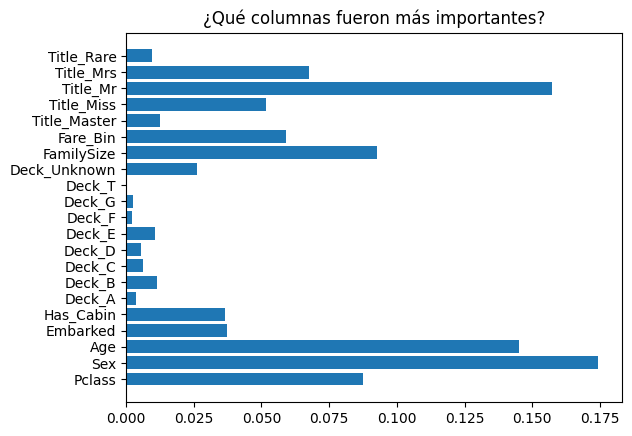

In [15]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
columns = X.columns
plt.barh(columns, importances)
plt.title("¿Qué columnas fueron más importantes?")
plt.show()

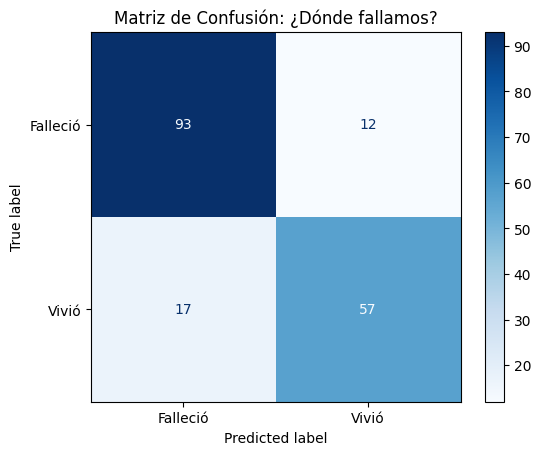

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Falleció', 'Vivió'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión: ¿Dónde fallamos?")
plt.show()

/tmp/ipykernel_16/935077819.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(train_df[train_df['Survived'] == 1]['Age'], label='Sobrevivió', shade=True, color="orange")
/tmp/ipykernel_16/935077819.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(train_df[train_df['Survived'] == 0]['Age'], label='Falleció', shade=True, color="blue")


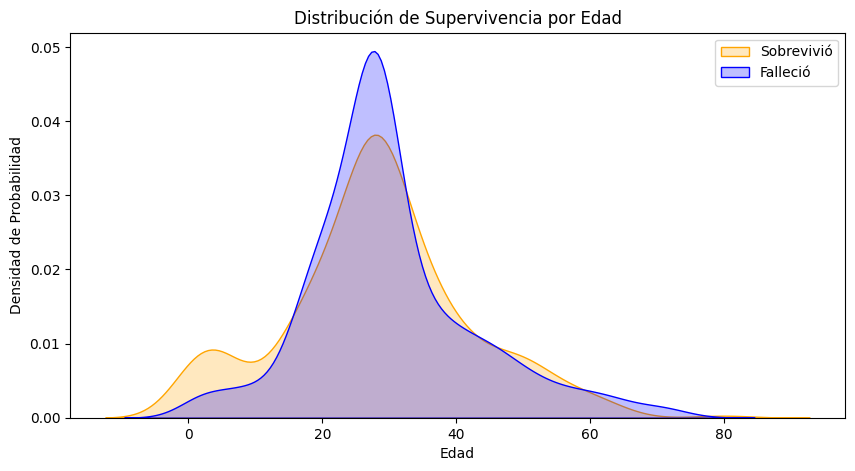

In [17]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.kdeplot(train_df[train_df['Survived'] == 1]['Age'], label='Sobrevivió', shade=True, color="orange")
sns.kdeplot(train_df[train_df['Survived'] == 0]['Age'], label='Falleció', shade=True, color="blue")
plt.title("Distribución de Supervivencia por Edad")
plt.xlabel("Edad")
plt.ylabel("Densidad de Probabilidad")
plt.legend()
plt.show()